# Introductıon
* This notebook is provided to facilitate the practical work of subject Biomedical Data analysis 2023-2024.

It contains the description of a covid 19 database.

### The notebook includes:
* Importing libraries
* Data Importing
* Data Preprocessing
* Data Preparing & Cleaning

In [ ]:
import pandas as pd
import numpy as np


%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
import pickle



from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn import metrics
from sklearn.pipeline import Pipeline

#Resampling for imbalanced datasets
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter


# classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

#Dalex library for checking fairness
!pip install dalex

!pip install Fairlearn

!pip install --upgrade kaleido==0.2.1

# Install required linux packages for the headless browser
!sudo apt update && sudo apt-get install -y libnss3 libatk-bridge2.0-0 libcups2 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libxkbcommon0 libpango-1.0-0 libcairo2 libasound2
#Whatever you need


In [ ]:
import dalex as dx
import fairlearn
import kaleido

# disable user warnings
import warnings
warnings.filterwarnings("ignore", message="Found unknown categories")

# About The Dataset
#### This dataset contains anonymized Covid-19 patient-related information. The raw dataset consisted originally of 21 unique features and 1,048,576 unique patients. However, the dataset has been preprocessed to delete variables with too many missing values (2 variables) and keeping only patients with positive COVID-19 test (387.596).

The features included

* sex: female or male
* age: of the patient.
* classification: covid test findings. Values 1-3 mean covid in different degrees.
* patient type: hospitalized or not hospitalized.
* pneumonia: whether the patient already have air sacs inflammation or not.
* pregnancy: whether the patient is pregnant or not.
* diabetes: whether the patient has diabetes or not.
* copd: Indicates whether the patient has Chronic obstructive pulmonary disease or not.
* asthma: whether the patient has asthma or not.
* inmsupr: whether the patient is immunosuppressed or not.
* hypertension: whether the patient has hypertension or not.
* cardiovascular: whether the patient has heart or blood vessels related disease.
* renal chronic: whether the patient has chronic renal disease or not.
* other disease: whether the patient has other disease or not.
* obesity: whether the patient is obese or not.
* tobacco: whether the patient is a tobacco user.
* usmr: Indicates whether the patient treated medical units of the first, second or third level.
* medical unit: type of institution of the National Health System that provided the care.
* death: indicates whether the patient died or recovered.

All boolean variables have been transformed so that, 1 means "yes" and 0 means "no". Sex has been kept as categorical.

# ** 1. Task**

# Overview Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/ A KISA/Biomedical Data Analysis/Project/Biomed_project_2 #Maddi's path

/content/drive/MyDrive/ A KISA/Biomedical Data Analysis/Project/Biomed_project_2


In [ ]:
df_C19 = pd.read_csv("Covid19.csv")
print("Shape of df :",df_C19.shape)
df_C19.head()

Shape of df : (387596, 20)


,Unnamed: 0,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,DEATH,CLASIFFICATION_FINAL
0,0,0,1,Female,1,1,65,0,0,0,0,0,1,0,0,0,0,0,1,3
1,2,0,1,Male,0,0,55,0,1,0,0,0,0,0,0,0,0,0,1,3
2,4,0,1,Male,1,0,68,0,1,0,0,0,1,0,0,0,0,0,1,3
3,5,0,1,Female,0,1,40,0,0,0,0,0,0,0,0,0,0,0,0,3
4,6,0,1,Female,1,0,64,0,0,0,0,0,0,0,0,0,0,0,0,3


In [ ]:
df_C19.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387596 entries, 0 to 387595
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Unnamed: 0            387596 non-null  int64 
 1   USMER                 387596 non-null  int64 
 2   MEDICAL_UNIT          387596 non-null  int64 
 3   SEX                   387596 non-null  object
 4   PATIENT_TYPE          387596 non-null  int64 
 5   PNEUMONIA             387596 non-null  int64 
 6   AGE                   387596 non-null  int64 
 7   PREGNANT              387596 non-null  int64 
 8   DIABETES              387596 non-null  int64 
 9   COPD                  387596 non-null  int64 
 10  ASTHMA                387596 non-null  int64 
 11  INMSUPR               387596 non-null  int64 
 12  HIPERTENSION          387596 non-null  int64 
 13  OTHER_DISEASE         387596 non-null  int64 
 14  CARDIOVASCULAR        387596 non-null  int64 
 15  OBESITY          

# ** 1. Task**

# Overview Dataset

In [ ]:
df_C19=df_C19.drop("Unnamed: 0", axis=1)

In [ ]:
df_C19.nunique()

,0
USMER,2
MEDICAL_UNIT,13
SEX,2
PATIENT_TYPE,2
PNEUMONIA,2
AGE,108
PREGNANT,2
DIABETES,2
COPD,2
ASTHMA,2


In [ ]:
df_C19.SEX.value_counts()


,count
SEX,
Male,207594
Female,180002


There are 2000 more male patiensd compared to females.

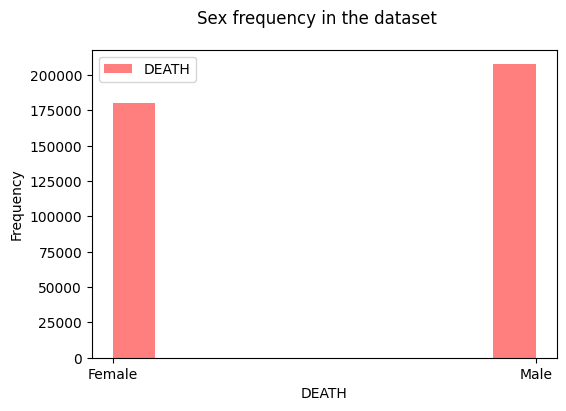

In [ ]:
fig, ax = plt.subplots(figsize = (6,4))

ax.hist(df_C19.SEX, alpha=0.5, color="red", label="DEATH")

ax.set_xlabel("DEATH")
ax.set_ylabel("Frequency")

fig.suptitle("Sex frequency in the dataset")

ax.legend();

In [ ]:
df_C19.CLASIFFICATION_FINAL.value_counts()

,count
CLASIFFICATION_FINAL,
3,377378
1,8417
2,1801


In [ ]:
df_C19.DEATH.value_counts()

,count
DEATH,
0,334274
1,53322


The dataset is very imbalanced:

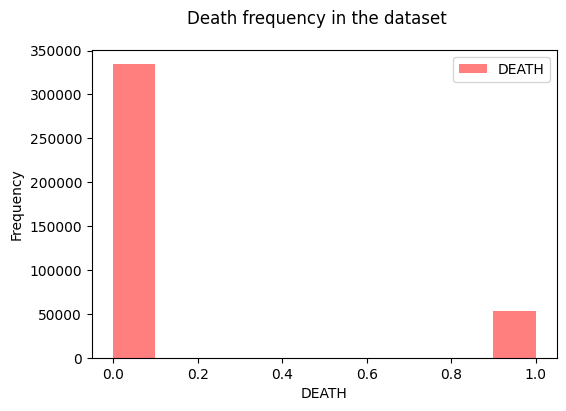

In [ ]:
fig, ax = plt.subplots(figsize = (6,4))

ax.hist(df_C19.DEATH, alpha=0.5, color="red", label="DEATH")

ax.set_xlabel("DEATH")
ax.set_ylabel("Frequency")

fig.suptitle("Death frequency in the dataset")

ax.legend();

Let's see if sex seems to be a determinant for death:

In [ ]:
total_sex_counts = df_C19['SEX'].value_counts()

death_cases = df_C19[df_C19['DEATH'] == 1]

death_counts_by_sex = death_cases['SEX'].value_counts()

percentage_death_by_sex = (death_counts_by_sex / total_sex_counts) * 100

print("\nPercentage of Death by Sex:")
print(percentage_death_by_sex)


Percentage of Death by Sex:
SEX
Male      16.698459
Female    10.364885
Name: count, dtype: float64


Male patients seem to have a higher risk of death compared to the females. However, since our database contains more males than females, this gives us a tighter margin of error and higher statistical confidence in the male mortality rate compared to the female.

## **Train/test splitting**

Train dataset will contain 70% of the patients of the original dataset and test dataset the remaining 30%.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df_C19.drop("DEATH", axis =1),
                                                    df_C19.DEATH,
                                                    test_size=0.3,
                                                    random_state=123)

print('Shape of training feature:', X_train.shape)
print('Shape of testing feature:', X_test.shape)
print('Shape of training label:', y_train.shape)
print('Shape of training label:', y_test.shape)
print(f"Training target statistics: {Counter(y_train)}")

Shape of training feature: (271317, 18)
Shape of testing feature: (116279, 18)
Shape of training label: (271317,)
Shape of training label: (116279,)
Training target statistics: Counter({0: 234164, 1: 37153})


Since the death frequency was very unbalanced, the training sample will be undersampled to obtain a similar ammount of instances.

In [ ]:
#Resample training sample. Undersample it to obtain a balanced sample
under_sampler = RandomUnderSampler(random_state=123)
X_train, y_train = under_sampler.fit_resample(X_train, y_train)
print(f"Training target statistics: {Counter(y_train)}")
print(f"Testing target statistics: {Counter(y_test)}")

Training target statistics: Counter({0: 37153, 1: 37153})
Testing target statistics: Counter({0: 100110, 1: 16169})


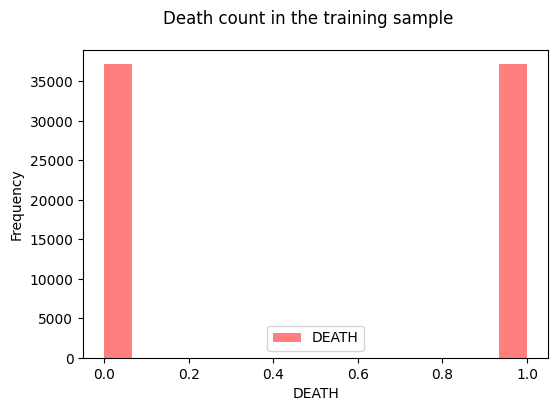

In [ ]:
fig, ax = plt.subplots(figsize = (6,4))

ax.hist(y_train, bins=15, alpha=0.5, color="red", label="DEATH")

ax.set_xlabel("DEATH")
ax.set_ylabel("Frequency")

fig.suptitle("Death count in the training sample")

ax.legend();

However, the test sample is still imbalanced, keeping the original distribution:

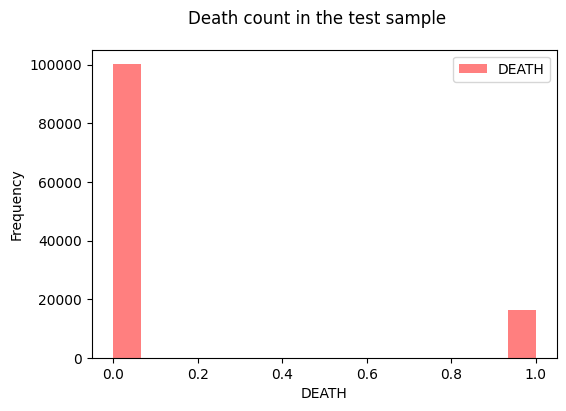

In [ ]:
fig, ax = plt.subplots(figsize = (6,4))

ax.hist(y_test, bins=15, alpha=0.5, color="red", label="DEATH")

ax.set_xlabel("DEATH")
ax.set_ylabel("Frequency")

fig.suptitle("Death count in the test sample")

ax.legend();

## **Data Preprocessing and training**

We will leave the binary variables as they are, encoded with values 0 and 1. We will use one-hot encoding with the variable 'CLASIFFICATION_FINAL' and 'MEDICAL_UNIT', and the numeric feature 'AGE' will be scaled with min-max scaler. In this way, all the variables will take values between 0 and 1

In [ ]:
#Onehot encoder for categorical features
categorical_features = ['USMER', 'SEX', 'PATIENT_TYPE','PNEUMONIA','PREGNANT','DIABETES','COPD','ASTHMA','INMSUPR','HIPERTENSION','OTHER_DISEASE',
                        'CARDIOVASCULAR','OBESITY','RENAL_CHRONIC','TOBACCO','CLASIFFICATION_FINAL', 'MEDICAL_UNIT']
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
])

#Scaling for numerical features
numerical_features = ['AGE' ]
numerical_transformer = Pipeline(steps=[
    ('scale', MinMaxScaler())
])

preprocessor = ColumnTransformer(transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numerical_transformer, numerical_features)
])


For this task, we selected four distinct classifiers: a Support Vector Machine (SVM) utilizing a Radial Basis Function (RBF) kernel, Random Forest, Logistic Regression, and a Multi-layer Perceptron.

In [ ]:
#Build the classifiers

#mlp
clf_mlp = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(random_state=123, max_iter=300))
])

Hyperparameter tuning:

In [ ]:
param_mlp={'classifier__hidden_layer_sizes':[(50,), (100,)], 'classifier__learning_rate':['constant','invscaling', 'adaptive'],
           'classifier__alpha':[0.0001, 0.001, 0.01]}

In [ ]:
#grid_mlp=GridSearchCV(clf_mlp, param_mlp, verbose=2)
#grid_mlp.fit(X_train, y_train)
#clf_mlp=grid_mlp.best_estimator_

Save the classifiers onde trained:

In [ ]:
#pickle.dump(clf_mlp, open('clf_mlp2.sav', 'wb'))

Load the trained and saved classifiers:

In [ ]:

# Load models directly from the active working directory
clf_mlp = pickle.load(open('clf_mlp2.sav', 'rb'))

The optimal parameters:

In [ ]:
print(clf_mlp.get_params)

<bound method Pipeline.get_params of Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore'))]),
                                                  ['USMER', 'SEX',
                                                   'PATIENT_TYPE', 'PNEUMONIA',
                                                   'PREGNANT', 'DIABETES',
                                                   'COPD', 'ASTHMA', 'INMSUPR',
                                                   'HIPERTENSION',
                                                   'OTHER_DISEASE',
                                                   'CARDIOVASCULAR', 'OBESITY',
                                                   'RENAL_CHRONIC', 'T

In [ ]:
exp_mlp = dx.Explainer(clf_mlp, X_test, y_test)

Preparation of a new explainer is initiated

  -> data              : 116279 rows 18 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 116279 values
  -> model_class       : sklearn.neural_network._multilayer_perceptron.MLPClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x7f179183d580> will be used (default)
  -> predict function  : Accepts only pandas.DataFrame, numpy.ndarray causes problems.
  -> predicted values  : min = 2.28e-05, mean = 0.262, max = 1.0
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.994, mean = -0.123, max = 0.999
  -> model_info        : package sklearn

A new explainer has been created!


# 2.Task

The provided data has been collected from 13 different medical units (MEDICAL_UNIT feature) of National Health
System. Assume that these units are not allowed to share their data among them due to strict privacy preserving
regulations. However, with this database they made an exception in order to analyze the quality of the models in
a federated learning framework and depending on these results they will make an investment and set up this
framework.


We have previously trained a Multi-Layer Perceptron classifier in a 'no federated framework'. This are the results:

In [ ]:
exp_mlp.model_performance().result

,recall,precision,f1,accuracy,auc
MLPClassifier,0.948667,0.475584,0.633555,0.847402,0.940961


Analyze the heterogeneity of the data according to the feature MEDICAL_UNIT: number of examples in
each unit and its class distribution.


In [ ]:
np.unique(df_C19.MEDICAL_UNIT)

array([ 0,  1,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])

In [ ]:
grouped = df_C19.groupby('MEDICAL_UNIT')
grouped_dict = {}
for name, group in grouped:
    group_name = f'df_{name}'
    grouped_dict[group_name] = group

Number of examples in each unit:

In [ ]:
for name in grouped_dict:
  negative=np.sum(grouped_dict[name].DEATH==0)
  samples=grouped_dict[name].shape[0]
  print(name, ':\n Number of samples =', samples, '\n Class distribution ---> ', 'class 0:', negative, ', class 1: ', samples-negative, '\n')

df_0 :
 Number of samples = 12 
 Class distribution --->  class 0: 12 , class 1:  0 

df_1 :
 Number of samples = 40 
 Class distribution --->  class 0: 37 , class 1:  3 

df_3 :
 Number of samples = 8581 
 Class distribution --->  class 0: 7439 , class 1:  1142 

df_4 :
 Number of samples = 126409 
 Class distribution --->  class 0: 98982 , class 1:  27427 

df_5 :
 Number of samples = 2847 
 Class distribution --->  class 0: 2432 , class 1:  415 

df_6 :
 Number of samples = 17358 
 Class distribution --->  class 0: 13460 , class 1:  3898 

df_7 :
 Number of samples = 409 
 Class distribution --->  class 0: 383 , class 1:  26 

df_8 :
 Number of samples = 4931 
 Class distribution --->  class 0: 3992 , class 1:  939 

df_9 :
 Number of samples = 14017 
 Class distribution --->  class 0: 13156 , class 1:  861 

df_10 :
 Number of samples = 3678 
 Class distribution --->  class 0: 3057 , class 1:  621 

df_11 :
 Number of samples = 3730 
 Class distribution --->  class 0: 3403 , class 

We can see that depending on the unit we have different levels of unbalancing, both for the number of examples (units with a lot of data, and units with little data), and for the ratio of the classes to predict (most of the times, we have more examples for class 0 compared to the examples for class 1).

## Federated Learning

First, we check that the version of Python installed is the correct one, then we install the required packages for creating a Federated Learning scheme.

In [ ]:
!python --version

Python 3.11.13


Performance metrics for each subroup of of the sex variable:

In [ ]:
!pip install tensorflow-federated==0.87.0 --no-deps
!pip install jax==0.4.28 jaxlib==0.4.28
!pip install dm-tree attrs dp-accounting google-vizier

  Using cached tensorflow_federated-0.87.0-py3-none-manylinux_2_31_x86_64.whl.metadata (19 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 MB 13.7 MB/s eta 0:00:00
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.5.1
    Uninstalling jaxlib-0.5.1:
      Successfully uninstalled jaxlib-0.5.1
  Attempting uninstall: jax
    Found existing installation: jax 0.5.2
    Uninstalling jax-0.5.2:
      Successfully uninstalled jax-0.5.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-federated 0.87.0 requires dp-accounting==0.4.3, which is not installed.
tensorflow-federated 0.87.0 requires google-vizier==0.1.11, which is not installed.
tensorflow-federated 0.87.0 requires

In [ ]:
import tensorflow_federated as tff
print(tff.__version__)

KeyboardInterrupt: 

In [ ]:
import time

import pandas as pd
import numpy as np
import math as m
import collections

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn import metrics
from sklearn.pipeline import Pipeline

In [ ]:
import tensorflow_federated as tff
import tensorflow as tf

ModuleNotFoundError: No module named 'tensorflow_federated'

In [ ]:
!pip show tensorflow-federated # 0.52.0
!pip show tensorflow # 2.11.0

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

We read the input data file, and we preprocess it to be able to train our models. The medical unit 0 will not take part in this model, because all the patients of this unit are from the class 0. So, we can't learn a Multi-layer Perceptron classifier with data that contains patients that are all from the same class. In addition, we have applied one-hot encoding the the categorical feature 'CLASSIFICATION_FINAL'.

In [ ]:
df_C19 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/BiomedicalDA/PracticalWork/Covid19.csv")

#df_C19 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/KISA/BDA_KISA/PracticalWork/Covid19.csv")

print("Shape of df :", df_C19.shape)
df_C19['SEX'] = df_C19['SEX'].replace({'Male': 0, 'Female': 1})
df_C19=df_C19.drop("Unnamed: 0", axis=1)

onehot=OneHotEncoder()
onehot.fit(df_C19['CLASIFFICATION_FINAL'].to_numpy().reshape(-1, 1))
one_columns=onehot.transform(df_C19['CLASIFFICATION_FINAL'].to_numpy().reshape(-1, 1)).toarray()
df_C19 = df_C19.drop('CLASIFFICATION_FINAL', axis=1)
df_C19 = pd.concat([df_C19,pd.DataFrame(one_columns, columns=['clas1', 'clas2', 'clas3'])], axis=1)
df_C19.head()
print("Shape of df :", df_C19.shape)

df_C19=df_C19[df_C19.MEDICAL_UNIT!=0]
print("Shape of df :", df_C19.shape)
df_C19.head()

In [ ]:
np.unique(df_C19.MEDICAL_UNIT)

We create a baseline:

In [ ]:
def create_keras_model():
    return tf.keras.models.Sequential([
        tf.keras.layers.InputLayer(input_shape=(19,)),
        tf.keras.layers.Dense(100),
        tf.keras.layers.Dense(2, activation='softmax'),
    ])

In [ ]:
train_df, test_df = train_test_split(df_C19, test_size=0.3, random_state=42)

# Define categorical and numerical features
categorical_features = ['USMER', 'SEX', 'PATIENT_TYPE', 'PNEUMONIA', 'PREGNANT', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'CLASIFFICATION_FINAL', 'MEDICAL_UNIT']
numerical_features = ['AGE']

# Define preprocessing pipeline
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
])
numerical_transformer = Pipeline(steps=[
    ('scale', MinMaxScaler())
])
preprocessor = ColumnTransformer(transformers=[
        ('num', numerical_transformer, numerical_features)
], remainder='passthrough')

X_train = preprocessor.fit_transform(train_df)
X_test = preprocessor.transform(test_df)
y_train = train_df['DEATH'].values
y_test = test_df['DEATH'].values

In [ ]:
# Compile and train the model
model = create_keras_model()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

### Initialize the executor

We will simulate our clients usint nest_asyncio package.

In [ ]:
# By design asyncio does not allow its event loop to be nested.
!pip3 install nest_asyncio
import nest_asyncio
nest_asyncio.apply()

We check if Tensorflow Federated is working:

In [ ]:
# test
np.random.seed(0)
tff.federated_computation(lambda: 'Hello, World!')()

Here, the clients are identified using the MEDICAL_UNIT feature of our data, where each MEDICAL_UNIT will have its own data. For example, the one client is trained using the MEDICAL_UNIT=1 data, i.e., using all the rows where the feature MEDICAL_UNIT equals 1, creating a "private" dataset for each client.

In [ ]:
NUM_CLIENTS = len(np.unique(df_C19.MEDICAL_UNIT))

executor_factory = tff.framework.local_executor_factory(clients_per_thread=NUM_CLIENTS)
execution_context = tff.framework.SyncExecutionContext(executor_fn=executor_factory)
tff.framework.set_default_context(execution_context)

As stated before, we create a private dataset for each client, i.e., each medical unit identified by the feature MEDICAL_UNIT. Then, we split each private dataset using a hold-out strategy, using the 70% of the data for training and 30% for testing.

In [ ]:
# A function which takes a client_id and returns a # tf.data.Dataset for that client,
# each client is a medical unit

def create_tf_dataset_for_client(client_id, df, SPLIT):
    # Select only the chunk of data for a particular medical unit (client_id)

    df_client = df[df["MEDICAL_UNIT"] == client_id]
    df_client = df_client.drop('MEDICAL_UNIT', axis=1)

    X_train, X_test, y_train, y_test = train_test_split(
        df_client.drop("DEATH", axis=1),
        df_client.DEATH,
        test_size=0.3,
        random_state=12
    )

    if(SPLIT=="training"):
        data = X_train
        labels = y_train

    else:
        data = X_test
        labels = y_test

    #mixmax scaler for feature AGE
    minimo = min(data['AGE'])
    maximo = max(data['AGE'])
    for row in range(0, data.shape[0]):
        data.iloc[row, 4] = ((data.iloc[row, 4] - minimo)/ (maximo - minimo))

    # Create database
    data_all = {'label':labels, 'vector':data}
    dataset = tf.data.Dataset.from_tensor_slices(data_all)
    return dataset

# client_id is a medical unit
def create_tf_dataset_for_client_tr(client_id):
    return create_tf_dataset_for_client(client_id, df_C19, "training")

def create_tf_dataset_for_client_ts(client_id):
    return create_tf_dataset_for_client(client_id, df_C19, "testing")

client_ids = list(np.unique(df_C19.MEDICAL_UNIT))

train_data = tff.simulation.datasets.ClientData.from_clients_and_tf_fn(
    client_ids=client_ids,
    serializable_dataset_fn=create_tf_dataset_for_client_tr
)

test_data = tff.simulation.datasets.ClientData.from_clients_and_tf_fn(
    client_ids=client_ids,
    serializable_dataset_fn=create_tf_dataset_for_client_ts
)

We create a function to adapt the datasets to tensorflow, and make the computation faster.

In [ ]:
NUM_EPOCHS = 2
BATCH_SIZE = 128
SHUFFLE_BUFFER = 100
PREFETCH_BUFFER = 10

def preprocess(dataset):
    def batch_format_fn(element):
        return collections.OrderedDict(
            x=element['vector'],
            y=tf.reshape(element['label'], [-1, 1])
        )
    return dataset.repeat(NUM_EPOCHS).shuffle(SHUFFLE_BUFFER, seed=1).batch(BATCH_SIZE).map(batch_format_fn).prefetch(PREFETCH_BUFFER)

We adapt all the private datasets of all the clients (medical units).

In [ ]:
def make_federated_data(client_data, client_ids):
    return [
        preprocess(client_data.create_tf_dataset_for_client(x))
        for x in client_ids
    ]

We check that our previous implementation works correctly:

In [ ]:
sample_clients = train_data.client_ids[0:NUM_CLIENTS]

federated_train_data = make_federated_data(train_data, sample_clients)
federated_test_data = make_federated_data(test_data, sample_clients)
print(f'Number of client datasets: {len(federated_train_data)}')
print(f'First dataset: {federated_train_data[0]}')

Create the Keras model, defining the loss function, metrics to compute, etc.

In [ ]:
def model_fn():
    # We _must_ create a new model here, and _not_ capture it from an external
    # scope. TFF will call this within different graph contexts.
    keras_model = create_keras_model()
    return tff.learning.from_keras_model(
        keras_model,
        input_spec=federated_train_data[0].element_spec,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
    )

Finally, we will train the MLP classifier in a federated framework, using s aggregation
method FedSGD and weighted and unweighted versions of FedAvg and FedProx. We have also plotted the progression of the loss function and accuracy with respect to the number of rounds.

### FedaAvg weighted

In [ ]:
federated_weighted_averaging_process = tff.learning.algorithms.build_weighted_fed_avg(
    model_fn,
    client_optimizer_fn=lambda: tf.keras.optimizers.SGD(learning_rate=0.02),
    server_optimizer_fn=lambda: tf.keras.optimizers.SGD(learning_rate=1.0)
)

In [ ]:
print(federated_weighted_averaging_process.initialize.type_signature.formatted_representation())

In [ ]:
NUM_ROUNDS = 20

# evaluation
evaluation_process = tff.learning.algorithms.build_fed_eval(model_fn)
evaluation_state = evaluation_process.initialize()

# train
# Let's invoke the initialize computation to construct the server state.
train_state = federated_weighted_averaging_process.initialize()
accu_tr = []
loss_tr = []
accu_ts = []
loss_ts = []
for round_num in range(0, NUM_ROUNDS):
    start_time = time.time()
    # next, represents a single round of FedAvg: decentralized federated computation
    result = federated_weighted_averaging_process.next(train_state, federated_train_data)
    train_state = result.state
    # obtain weights
    model_weights = federated_weighted_averaging_process.get_model_weights(train_state)
    evaluation_state = evaluation_process.set_model_weights(evaluation_state, model_weights)
    # eval train
    evaluation_output = evaluation_process.next(evaluation_state, federated_train_data)
    train_metrics = evaluation_output.metrics
    # eval test
    evaluation_output = evaluation_process.next(evaluation_state, federated_test_data)
    test_metrics = evaluation_output.metrics

    end_time = time.time()
    elapsed_time = end_time - start_time
    # print('round {:2d}, metrics={}'.format(round_num, train_metrics))
    print('round={:2d}, metrics={:.4f}, seconds={:.2f}, accuracy={:.4f}'.format(
        round_num,
        train_metrics['client_work']['eval']['current_round_metrics']['loss'],
        elapsed_time,
        test_metrics['client_work']['eval']['current_round_metrics']['sparse_categorical_accuracy']))
    accu_tr.append(train_metrics['client_work']['eval']['current_round_metrics']['sparse_categorical_accuracy'])
    loss_tr.append(train_metrics['client_work']['eval']['current_round_metrics']['loss'])
    accu_ts.append(test_metrics['client_work']['eval']['current_round_metrics']['sparse_categorical_accuracy'])
    loss_ts.append(test_metrics['client_work']['eval']['current_round_metrics']['loss'])

In [ ]:
import matplotlib.pyplot as plt
x = list(range(NUM_ROUNDS))
plt.plot(x, loss_tr)
plt.plot(x, loss_ts)
plt.xlabel('rounds')
plt.ylabel('loss')
plt.show()

In [ ]:
plt.plot(x, accu_tr)
plt.plot(x, accu_ts)
plt.xlabel('rounds')
plt.ylabel('accu')
plt.ylim(0,1)
plt.show()

### FedaAvg unweighted

In [ ]:
federated_unweighted_averaging_process = tff.learning.algorithms.build_unweighted_fed_avg(
    model_fn,
    client_optimizer_fn=lambda: tf.keras.optimizers.SGD(learning_rate=0.02),
    server_optimizer_fn=lambda: tf.keras.optimizers.SGD(learning_rate=1.0)
)

In [ ]:
print(federated_unweighted_averaging_process.initialize.type_signature.formatted_representation())

In [ ]:
NUM_ROUNDS = 20

# evaluation
evaluation_process = tff.learning.algorithms.build_fed_eval(model_fn)
evaluation_state = evaluation_process.initialize()

# train
# Let's invoke the initialize computation to construct the server state.
train_state = federated_unweighted_averaging_process.initialize()
accu_tr = []
loss_tr = []
accu_ts = []
loss_ts = []
for round_num in range(0, NUM_ROUNDS):
    start_time = time.time()
    # next, represents a single round of FedAvg: decentralized federated computation
    result = federated_unweighted_averaging_process.next(train_state, federated_train_data)
    train_state = result.state
    # obtain weights
    model_weights = federated_unweighted_averaging_process.get_model_weights(train_state)
    evaluation_state = evaluation_process.set_model_weights(evaluation_state, model_weights)
    # eval train
    evaluation_output = evaluation_process.next(evaluation_state, federated_train_data)
    train_metrics = evaluation_output.metrics
    # eval test
    evaluation_output = evaluation_process.next(evaluation_state, federated_test_data)
    test_metrics = evaluation_output.metrics
    end_time = time.time()
    elapsed_time = end_time - start_time
    # print('round {:2d}, metrics={}'.format(round_num, train_metrics))
    print('round={:2d}, metrics={:.4f}, seconds={:.2f}, accuracy={:.4f}'.format(
        round_num,
        train_metrics['client_work']['eval']['current_round_metrics']['loss'],
        elapsed_time,
        test_metrics['client_work']['eval']['current_round_metrics']['sparse_categorical_accuracy']))
    accu_tr.append(train_metrics['client_work']['eval']['current_round_metrics']['sparse_categorical_accuracy'])
    loss_tr.append(train_metrics['client_work']['eval']['current_round_metrics']['loss'])
    accu_ts.append(test_metrics['client_work']['eval']['current_round_metrics']['sparse_categorical_accuracy'])
    loss_ts.append(test_metrics['client_work']['eval']['current_round_metrics']['loss'])

In [ ]:
import matplotlib.pyplot as plt
x = list(range(NUM_ROUNDS))
plt.plot(x, loss_tr)
plt.plot(x, loss_ts)
plt.xlabel('rounds')
plt.ylabel('loss')
plt.show()

In [ ]:
plt.plot(x, accu_tr)
plt.plot(x, accu_ts)
plt.xlabel('rounds')
plt.ylabel('accu')
plt.ylim(0,1)
plt.show()

### FedSGD

In [ ]:
federated_sgd_process = tff.learning.algorithms.build_fed_sgd(
    model_fn,
    server_optimizer_fn=lambda: tf.keras.optimizers.SGD(learning_rate=1.0)
)

In [ ]:
print(federated_sgd_process.initialize.type_signature.formatted_representation())

In [ ]:
NUM_ROUNDS = 20

# evaluation
evaluation_process = tff.learning.algorithms.build_fed_eval(model_fn)
evaluation_state = evaluation_process.initialize()

# train
# Let's invoke the initialize computation to construct the server state.
train_state = federated_sgd_process.initialize()
accu_tr = []
loss_tr = []
accu_ts = []
loss_ts = []
for round_num in range(0, NUM_ROUNDS):
    start_time = time.time()
    # next, represents a single round of FedSGD: decentralized federated computation
    result = federated_sgd_process.next(train_state, federated_train_data)
    train_state = result.state
    # obtain weights
    model_weights = federated_sgd_process.get_model_weights(train_state)
    evaluation_state = evaluation_process.set_model_weights(evaluation_state, model_weights)
    # eval train
    evaluation_output = evaluation_process.next(evaluation_state, federated_train_data)
    train_metrics = evaluation_output.metrics
    # eval test
    evaluation_output = evaluation_process.next(evaluation_state, federated_test_data)
    test_metrics = evaluation_output.metrics
    end_time = time.time()
    elapsed_time = end_time - start_time
    # print('round {:2d}, metrics={}'.format(round_num, train_metrics))
    print('round={:2d}, metrics={:.4f}, seconds={:.2f}, accuracy={:.4f}'.format(
        round_num,
        train_metrics['client_work']['eval']['current_round_metrics']['loss'],
        elapsed_time,
        test_metrics['client_work']['eval']['current_round_metrics']['sparse_categorical_accuracy']))
    accu_tr.append(train_metrics['client_work']['eval']['current_round_metrics']['sparse_categorical_accuracy'])
    loss_tr.append(train_metrics['client_work']['eval']['current_round_metrics']['loss'])
    accu_ts.append(test_metrics['client_work']['eval']['current_round_metrics']['sparse_categorical_accuracy'])
    loss_ts.append(test_metrics['client_work']['eval']['current_round_metrics']['loss'])

In [ ]:
import matplotlib.pyplot as plt
x = list(range(NUM_ROUNDS))
plt.plot(x, loss_tr)
plt.plot(x, loss_ts)
plt.xlabel('rounds')
plt.ylabel('loss')
plt.show()

In [ ]:
plt.plot(x, accu_tr)
plt.plot(x, accu_ts)
plt.xlabel('rounds')
plt.ylabel('accu')
plt.ylim(0,1)
plt.show()

### FedProx weighted

In [ ]:
federated_fed_prox_weighted_process = tff.learning.algorithms.build_weighted_fed_prox(
    model_fn,
    proximal_strength=0.1,
    client_optimizer_fn=lambda: tf.keras.optimizers.SGD(learning_rate=0.02),
    server_optimizer_fn=lambda: tf.keras.optimizers.SGD(learning_rate=1.0)
)

In [ ]:
print(federated_fed_prox_weighted_process.initialize.type_signature.formatted_representation())

In [ ]:
NUM_ROUNDS = 20

# evaluation
evaluation_process = tff.learning.algorithms.build_fed_eval(model_fn)
evaluation_state = evaluation_process.initialize()

# train
# Let's invoke the initialize computation to construct the server state.
train_state = federated_fed_prox_weighted_process.initialize()
accu_tr = []
loss_tr = []
accu_ts = []
loss_ts = []
for round_num in range(0, NUM_ROUNDS):
    start_time = time.time()
    # next, represents a single round of FedProx: decentralized federated computation
    result = federated_fed_prox_weighted_process.next(train_state, federated_train_data)
    train_state = result.state
    # obtain weights
    model_weights = federated_fed_prox_weighted_process.get_model_weights(train_state)
    evaluation_state = evaluation_process.set_model_weights(evaluation_state, model_weights)
    # eval train
    evaluation_output = evaluation_process.next(evaluation_state, federated_train_data)
    train_metrics = evaluation_output.metrics
    # eval test
    evaluation_output = evaluation_process.next(evaluation_state, federated_test_data)
    test_metrics = evaluation_output.metrics
    end_time = time.time()
    elapsed_time = end_time - start_time
    # print('round {:2d}, metrics={}'.format(round_num, train_metrics))
    print('round={:2d}, metrics={:.4f}, seconds={:.2f}, accuracy={:.4f}'.format(
        round_num,
        train_metrics['client_work']['eval']['current_round_metrics']['loss'],
        elapsed_time,
        test_metrics['client_work']['eval']['current_round_metrics']['sparse_categorical_accuracy']))
    accu_tr.append(train_metrics['client_work']['eval']['current_round_metrics']['sparse_categorical_accuracy'])
    loss_tr.append(train_metrics['client_work']['eval']['current_round_metrics']['loss'])
    accu_ts.append(test_metrics['client_work']['eval']['current_round_metrics']['sparse_categorical_accuracy'])
    loss_ts.append(test_metrics['client_work']['eval']['current_round_metrics']['loss'])

In [ ]:
import matplotlib.pyplot as plt
x = list(range(NUM_ROUNDS))
plt.plot(x, loss_tr)
plt.plot(x, loss_ts)
plt.xlabel('rounds')
plt.ylabel('loss')
plt.show()

In [ ]:
plt.plot(x, accu_tr)
plt.plot(x, accu_ts)
plt.xlabel('rounds')
plt.ylabel('accu')
plt.ylim(0,1)
plt.show()

### FedProx unweighted

In [ ]:
federated_fed_prox_unweighted_process = tff.learning.algorithms.build_unweighted_fed_prox(
    model_fn,
    proximal_strength=0.1,
    client_optimizer_fn=lambda: tf.keras.optimizers.SGD(learning_rate=0.02),
    server_optimizer_fn=lambda: tf.keras.optimizers.SGD(learning_rate=1.0)
)

In [ ]:
print(federated_fed_prox_unweighted_process.initialize.type_signature.formatted_representation())

In [ ]:
NUM_ROUNDS = 20

# evaluation
evaluation_process = tff.learning.algorithms.build_fed_eval(model_fn)
evaluation_state = evaluation_process.initialize()

# train
# Let's invoke the initialize computation to construct the server state.
train_state = federated_fed_prox_unweighted_process.initialize()
accu_tr = []
loss_tr = []
accu_ts = []
loss_ts = []
for round_num in range(0, NUM_ROUNDS):
    start_time = time.time()
    # next, represents a single round of FedProx: decentralized federated computation
    result = federated_fed_prox_unweighted_process.next(train_state, federated_train_data)
    train_state = result.state
    # obtain weights
    model_weights = federated_fed_prox_unweighted_process.get_model_weights(train_state)
    evaluation_state = evaluation_process.set_model_weights(evaluation_state, model_weights)
    # eval train
    evaluation_output = evaluation_process.next(evaluation_state, federated_train_data)
    train_metrics = evaluation_output.metrics
    # eval test
    evaluation_output = evaluation_process.next(evaluation_state, federated_test_data)
    test_metrics = evaluation_output.metrics
    end_time = time.time()
    elapsed_time = end_time - start_time
    # print('round {:2d}, metrics={}'.format(round_num, train_metrics))
    print('round={:2d}, metrics={:.4f}, seconds={:.2f}, accuracy={:.4f}'.format(
        round_num,
        train_metrics['client_work']['eval']['current_round_metrics']['loss'],
        elapsed_time,
        test_metrics['client_work']['eval']['current_round_metrics']['sparse_categorical_accuracy']))
    accu_tr.append(train_metrics['client_work']['eval']['current_round_metrics']['sparse_categorical_accuracy'])
    loss_tr.append(train_metrics['client_work']['eval']['current_round_metrics']['loss'])
    accu_ts.append(test_metrics['client_work']['eval']['current_round_metrics']['sparse_categorical_accuracy'])
    loss_ts.append(test_metrics['client_work']['eval']['current_round_metrics']['loss'])

In [ ]:
import matplotlib.pyplot as plt
x = list(range(NUM_ROUNDS))
plt.plot(x, loss_tr)
plt.plot(x, loss_ts)
plt.xlabel('rounds')
plt.ylabel('loss')
plt.show()

In [ ]:
plt.plot(x, accu_tr)
plt.plot(x, accu_ts)
plt.xlabel('rounds')
plt.ylabel('accu')
plt.ylim(0,1)
plt.show()